<a href="https://colab.research.google.com/github/arifkur27/sistem_rekomendasi_jurnal.ipynb/blob/main/Rekomendasi_referensi_jurnal_senatib.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv(
    '/content/drive/MyDrive/SistemRekomendasi/SENATIB_490_ARTIKEL.csv'
)

df.head()

,judul,penulis,tanggal,abstrak,link
0,PERANCANGAN APLIKASI DETEKSI RISIKO TINGGI PAD...,"Rifqi Firdausi Arafad, Joni Maulindar, Dwi Har...",Publish Date 29 Jun 2022 Abstract Risiko,Risiko tinggi kehamilan adalah suatu kehamilan...,https://garuda.kemdiktisaintek.go.id/documents...
1,Rancang Bangun Pengendalian Lampu Berdasarkan ...,"Azzah Nur Farida, Syaelan Raka Pramuja Ananda,...",Publish Date 25 Jul 2023 Abstract Peneli,Penelitian ini merancang suatu sistem control ...,https://garuda.kemdiktisaintek.go.id/documents...
2,Penerapan Algoritma Naïve Bayes Untuk Prediksi...,"Riyadi, Bagus, Saputra, Danang, Arum Sari, Apr...",Publish Date 26 Jul 2025 Abstract Penyak,Penyakit paru merupakan salah satu masalah kes...,https://garuda.kemdiktisaintek.go.id/documents...
3,SISTEM PENDUKUNG KEPUTUSAN PEMILIHAN UMBUL TER...,"Artdelia Pingkan Salsabilla, Fitriana Sekar Ki...",Publish Date 29 Jun 2022 Abstract Peneli,Penelitian ini dilakukan secara global ke bebe...,https://garuda.kemdiktisaintek.go.id/documents...
4,Sistem Kendali Kebakaran Otomatis Berbasis Sen...,"Ibnu Is’ad, Fadhil, Catur Pamungkas, Affandi",Publish Date 26 Jul 2025 Abstract Kebaka,Kebakaran merupakan bencana yang dapat terjadi...,https://garuda.kemdiktisaintek.go.id/documents...


In [3]:
print(df.shape)

print(df.columns)


(490, 5)
Index(['judul', 'penulis', 'tanggal', 'abstrak', 'link'], dtype='object')


In [4]:
df['tahun'] = (
    df['tanggal']
    .astype(str)
    .str.extract(r'(20\d{2})')
)

In [5]:
df[['tanggal','tahun']].head()

,tanggal,tahun
0,Publish Date 29 Jun 2022 Abstract Risiko,2022
1,Publish Date 25 Jul 2023 Abstract Peneli,2023
2,Publish Date 26 Jul 2025 Abstract Penyak,2025
3,Publish Date 29 Jun 2022 Abstract Peneli,2022
4,Publish Date 26 Jul 2025 Abstract Kebaka,2025


In [7]:
df.to_csv(
    '/content/drive/MyDrive/SistemRekomendasi/SENATIB_490_ARTIKEL_FIX.csv',
    index=False,
    encoding='utf-8-sig'
)

In [54]:
# ==========================================
# LANGKAH 4
# INSTALL LIBRARY
# ==========================================

# nltk
# digunakan untuk stopword

# sastrawi
# digunakan untuk stemming Bahasa Indonesia

# scikit-learn
# digunakan untuk TF-IDF dan Cosine Similarity

!pip install nltk sastrawi scikit-learn

In [55]:
# ==========================================
# LANGKAH 5
# IMPORT LIBRARY
# ==========================================
import re
import nltk

from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [56]:
# ==========================================
# LANGKAH 6
# DOWNLOAD STOPWORD
# ==========================================

# Stopword adalah kata yang tidak memiliki
# makna penting dalam proses pencarian
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [57]:
# ==========================================
# LANGKAH 7
# MEMBUAT STEMMER
# ==========================================
stop_words = set(
    stopwords.words('indonesian')
)

factory = StemmerFactory()

stemmer = factory.create_stemmer()

print("Berhasil")

Berhasil


In [58]:
# ==========================================
# LANGKAH 8
# PREPROCESSING
# ==========================================

# Tahapan:
# 1. Lowercase
# 2. Hapus angka
# 3. Hapus simbol
# 4. Tokenisasi
# 5. Stopword Removal
# 6. Stemming
def preprocessing(text):

    text = str(text)

    text = text.lower()

    text = re.sub(r'\d+', '', text)

    text = re.sub(r'[^\w\s]', '', text)

    tokens = text.split()

    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    tokens = [
        stemmer.stem(word)
        for word in tokens
    ]

    return " ".join(tokens)

In [59]:
# ==========================================
# LANGKAH 9
# MEMBERSIHKAN ABSTRAK
# ==========================================
df['abstrak'] = df['abstrak'].fillna('')

In [14]:
df['clean_abstrak'] = (
    df['abstrak']
    .apply(preprocessing)
)

In [15]:
df[['judul','clean_abstrak']].head()

,judul,clean_abstrak
0,PERANCANGAN APLIKASI DETEKSI RISIKO TINGGI PAD...,risiko hamil hamil yangmemiliki risiko maupunb...
1,Rancang Bangun Pengendalian Lampu Berdasarkan ...,teliti rancang sistem control lampu bas arduin...
2,Penerapan Algoritma Naïve Bayes Untuk Prediksi...,sakit paru salah sehat global tangan cepat aku...
3,SISTEM PENDUKUNG KEPUTUSAN PEMILIHAN UMBUL TER...,teliti global wisatamata air umbul camat tulun...
4,Sistem Kendali Kebakaran Otomatis Berbasis Sen...,bakar bencana tibatiba sebab rugi meminimalisi...


In [16]:
df.to_csv(
    '/content/drive/MyDrive/SistemRekomendasi/SENATIB_BERSIH.csv',
    index=False,
    encoding='utf-8-sig'
)

In [60]:
# ==========================================
# LANGKAH 11
# TF-IDF
# ==========================================

# Tujuan:
# Mengubah teks menjadi bentuk numerik
tfidf = TfidfVectorizer()

tfidf_matrix = tfidf.fit_transform(
    df['clean_abstrak']
)

print(tfidf_matrix.shape)

(490, 7240)


In [61]:
# ==========================================
# LANGKAH 12
# COSINE SIMILARITY
# ==========================================

# Tujuan:
# Menghitung kemiripan antar dokumen
cosine_sim = cosine_similarity(
    tfidf_matrix,
    tfidf_matrix
)

print(cosine_sim.shape)

(490, 490)


In [62]:
# ==========================================
# LANGKAH 13
# REKOMENDASI REFERENSI JURNAL
# ==========================================

# Tujuan:
# Pengguna memasukkan judul penelitian baru
# kemudian sistem mencari artikel yang
# paling relevan
def rekomendasi_judul_baru(judul_baru, top_n=5):

    judul_baru_clean = preprocessing(judul_baru)

    query_vector = tfidf.transform(
        [judul_baru_clean]
    )

    similarity = cosine_similarity(
        query_vector,
        tfidf_matrix
    ).flatten()

    indeks = similarity.argsort()[-top_n:][::-1]

    hasil = []

    for i in indeks:

        hasil.append({
            "Judul": df.iloc[i]['judul'],
            "Tahun": df.iloc[i]['tahun'],
            "Link": df.iloc[i]['link'],
            "Similarity": round(similarity[i],4)
        })

    return pd.DataFrame(hasil)

In [43]:
for i in df['judul'].head(20):
    print(i)

PERANCANGAN APLIKASI DETEKSI RISIKO TINGGI PADA KEHAMILAN MENGGUNAKAN ALGORITMA RANDOM FOREST BERBASIS MOBILE DI DESA BOLOPLERET KABUPATEN KLATEN
Rancang Bangun Pengendalian Lampu Berdasarkan Sensor Suara Berbasis Arduino Uno Dengan Kearifan Lokal
Penerapan Algoritma Naïve Bayes Untuk Prediksi Penyakit Paru (Studi Kasus : Rumah Sakit Umum Daerah Dokter Soeratno Gemolong)
SISTEM PENDUKUNG KEPUTUSAN PEMILIHAN UMBUL TERBAIK DI KECAMATAN TULUNG KLATEN MENGGUNAKAN METODE SMART
Sistem Kendali Kebakaran Otomatis Berbasis Sensor Suhu Dan Api Menggunakan Mikrokontroler
Penerapan Sensor Ultrasonik Pada Tempat Sampah Pintar Berbasis Arduino Uno
Prototipe Sistem Pendeteksi Anomali Berbasis Website Dengan Integrasi IoT Untuk Keamanan Area Kebun
Sistem Pendeteksi Kebakaran Otomatis di Rumah Tradisional Betang Suku Dayak
Rancang Bangun Alat Pendeteksi dan Monitoring Banjir Menggunakan ESP32
Sistem Pendukung Keputusan Pemilihan Mahasiswa Terbaik Menggunakan Metode Multi- Objective Optimization on The 

In [44]:
judul_uji = df['judul'].iloc[0]

print("Artikel Acuan:")
print(judul_uji)

rekomendasi_judul(judul_uji)

Artikel Acuan:
PERANCANGAN APLIKASI DETEKSI RISIKO TINGGI PADA KEHAMILAN MENGGUNAKAN ALGORITMA RANDOM FOREST BERBASIS MOBILE DI DESA BOLOPLERET KABUPATEN KLATEN


,Judul,Tahun,Link,Similarity
0,Pengembangan Klastering Untuk Penanganan Ibu H...,2023,https://garuda.kemdiktisaintek.go.id/documents...,0.2729
1,Sistem Cerdas Kesehatan Ibu Hamil Menggunakan ...,2022,https://garuda.kemdiktisaintek.go.id/documents...,0.2201
2,Perancangan Sistem Rekomendasi Tingkat Mortali...,2023,https://garuda.kemdiktisaintek.go.id/documents...,0.1843
3,Klasifikasi Jenis Persalinan pada Ibu Hamil de...,2022,https://garuda.kemdiktisaintek.go.id/documents...,0.1406
4,ANALISIS RISIKO KEAMANAN INFORMASI E-GOV SISKE...,2022,https://garuda.kemdiktisaintek.go.id/documents...,0.1244


In [37]:
df['judul'].sample(10)

,judul
256,Perancangan Sistem Rekomendasi Perbelanjaan it...
266,Penerapan Metode Regresi Linear Berganda Untuk...
125,SISTEM PENDUKUNG KEPUTUSAN PEMENANG UNDIAN BAN...
207,Pengujian Sistem Informasi Desa Wonokeling Men...
113,Perancangan Aplikasi Pengaduan Masyarakat Pada...
143,Perancangan Sistem Informasi Penjualan Sayuran...
203,Penerapan Regresi Linier Berganda Untuk Mempre...
434,Sistem Keamanan Motor Menggunakan Sensor Sidik...
60,Perancangan Sistem Informasi Stok Terdistribus...
410,Perancangan dan Implementasi Sistem Keamanan P...


In [65]:
# ==========================================
# LANGKAH 14
# PENGUJIAN SISTEM
# ==========================================
rekomendasi_judul_baru(
    "Sistem Rekomendasi Pemilihan Tempat Wisata Berbasis Web"
)

,Judul,Tahun,Link,Similarity
0,Optimasi Metode Knowledge Based Recommendation...,2023,https://garuda.kemdiktisaintek.go.id/documents...,0.2787
1,RANCANG BANGUN APLIKASI INFORMASI TEMPAT WISAT...,2022,https://garuda.kemdiktisaintek.go.id/documents...,0.2532
2,Sistem Rekomendasi Berbasis pengetahuan untuk ...,2023,https://garuda.kemdiktisaintek.go.id/documents...,0.2527
3,Virtual Reality : Analisis Minat Teknologi Int...,2022,https://garuda.kemdiktisaintek.go.id/documents...,0.1977
4,Analisis Sentimen Pada Ulasan Tempat Wisata De...,2025,https://garuda.kemdiktisaintek.go.id/documents...,0.1540


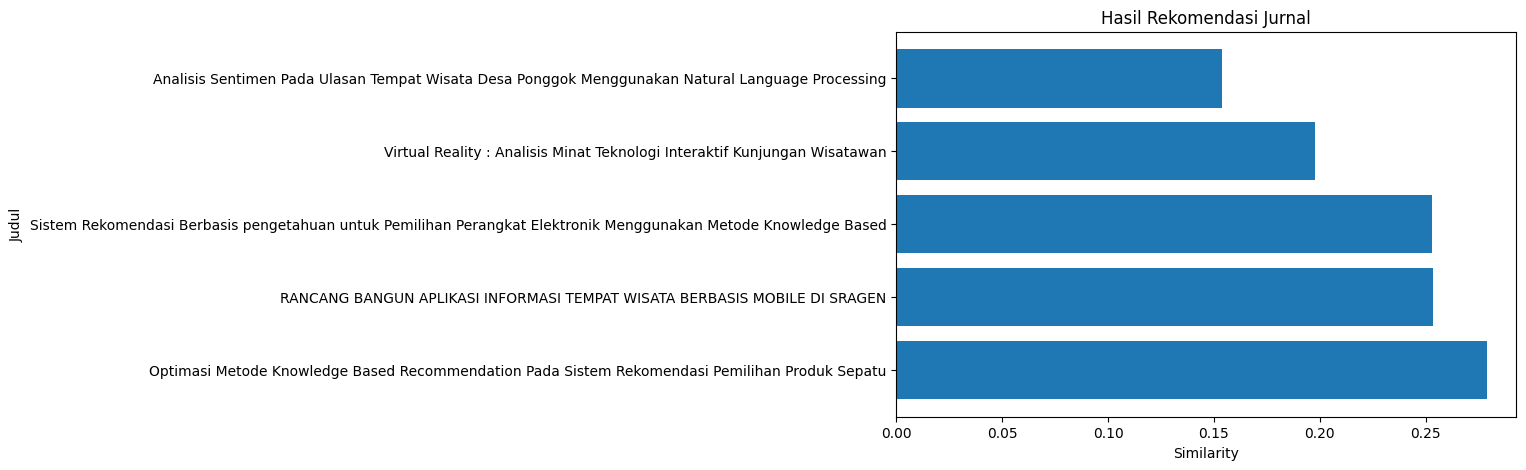

In [64]:
import matplotlib.pyplot as plt

hasil = rekomendasi_judul_baru(
    "Sistem Rekomendasi Pemilihan Tempat Wisata Berbasis Web"
)

plt.figure(figsize=(8,5))
plt.barh(
    hasil['Judul'],
    hasil['Similarity']
)
plt.xlabel('Similarity')
plt.ylabel('Judul')
plt.title('Hasil Rekomendasi Jurnal')
plt.show()